In [1]:
import pathlib
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import pandas as pd
import pingouin as pg
import seaborn as sns


import TwoPUtils as tpu
import STX3KO_analyses as stx

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42


%matplotlib inline

%load_ext autoreload
%autoreload 2
 

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/fig1_licks')
figdir.mkdir(exist_ok=True, parents=True)

In [3]:
sess = stx.utilities.load_vr_day('mCherry9',0,pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')

{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


In [4]:
sess.trial_info["LR"]
sess.novel_arm

-1

In [5]:
sess = stx.utilities.load_single_day('mCherry9', 0)
sess.novel_arm

{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


-1

In [7]:
rows = []
x = np.arange(-10,3)
for (cond, mice) in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    for day in range(6):
        
        print(day)
        for mouse in mice:

            if mouse == 'SparseKO_09' and day==2:
                continue
            print(mouse)
            sess = stx.utilities.load_vr_day(mouse, day, trial_mat_keys = ('nonconsum_licks','licks_sum', 'licks'),verbose = False, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls/')
            # if se
            # sess.novel_arm = stx.ymaze_sess_deets['']

            bin_edges = sess.trial_matrices['bin_edges']
            right_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            left_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            if sess.novel_arm==-1:
                rzone_nov = left_rzone_front
                rzone_fam = right_rzone_front
            else:
                rzone_nov = right_rzone_front
                rzone_fam = left_rzone_front

            for ttype in ('fam', 'nov'):
                
                if ttype == 'nov':
                    trial_mask = sess.trial_info["LR"] == sess.novel_arm
                    rzone = rzone_nov
                else:
                    trial_mask = sess.trial_info["LR"] != sess.novel_arm
                    rzone = rzone_fam

                
                licks = sess.trial_matrices['licks_sum'][trial_mask,:]
                rzone_licks = np.nanmean(licks[:,rzone-5:rzone+1], axis=0).sum()
                rzone_lick_plot_vec = np.nanmean(licks[:,rzone-10:rzone+3], axis=0)

                rows.append({'cond': cond,
                             'mouse': mouse,
                             'day': day,
                             'ttype': ttype,
                             'rzone_licks': rzone_licks,
                             'rzone_licks_plot_vec': rzone_lick_plot_vec,
                             })
df = pd.DataFrame(rows)
                
                

0
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
1
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
2
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
3
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
5
4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
0
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
1
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
2
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
3
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
4
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
5
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
0
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09
1
SparseKO_02


In [8]:
df.head()

,cond,mouse,day,ttype,rzone_licks,rzone_licks_plot_vec
0,ctrl,4467331.1,0,fam,5.691667,"[0.10833333333333334, 0.13333333333333333, 0.1..."
1,ctrl,4467331.1,0,nov,3.526316,"[0.05263157894736842, 0.05263157894736842, 0.0..."
2,ctrl,4467331.2,0,fam,6.727273,"[0.30578512396694213, 0.4297520661157025, 0.55..."
3,ctrl,4467331.2,0,nov,7.000000,"[0.6842105263157895, 1.0526315789473684, 0.894..."
4,ctrl,4467332.1,0,fam,15.220339,"[0.4915254237288136, 0.5169491525423728, 0.635..."


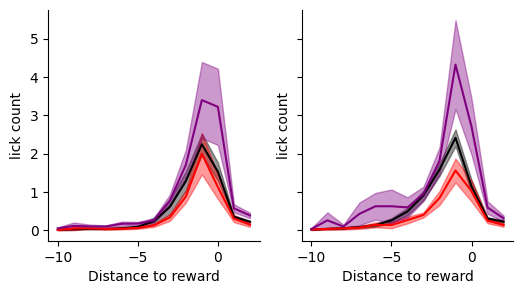

In [9]:
day = 5

x = np.arange(-10,3)
fig, ax =plt.subplots(1,2, sharey=True, sharex=True, figsize=[6,3])


ttype = 'fam'
cond = 'ctrl'
for cond, color in zip(('ctrl', 'ko', 'sparse'), ('black','red', 'purple')):
    for i, ttype in enumerate(('fam', 'nov')):

        mask = (df['cond']==cond) * (df['day']==day) * (df['ttype']==ttype)

        licks = np.vstack(df.loc[mask,'rzone_licks_plot_vec'].values)


        mu, sem = np.nanmean(licks, axis=0), sp.stats.sem(licks, axis=0, nan_policy='omit')
        ax[i].plot(x, mu, color=color)
        ax[i].fill_between(x, mu-sem, mu+sem, color=color, alpha=.4)

for a in ax.flatten():
    # a.fill_betweenx([0,10], -1, 2, alpha=.4, color='purple', zorder=-10)
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

    a.set_ylabel('lick count')
    a.set_xlabel('Distance to reward')
# fig.savefig(figdir / f"licks_v_position_day{day}.pdf")

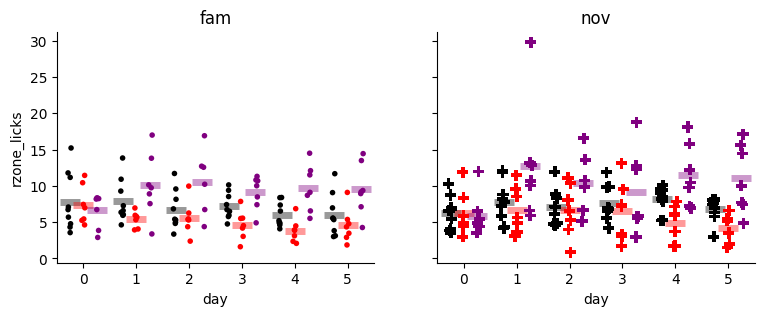

In [14]:


fig,ax = plt.subplots(1,2, figsize=[9,3], sharey = True)
for i, nov in enumerate(('fam','nov')):
    if nov == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=df.loc[df['ttype']==nov,:],
                x='day',
                y='rzone_licks',
                hue='cond', 
                hue_order=('ctrl', 'ko','sparse'), 
                palette=['black', 'red','purple'],
                dodge=True,
                ax=ax[i], marker = marker, s=s,
                legend=False)
    


    sns.pointplot(data=df.loc[df['ttype']==nov,:],
              x='day',
              y='rzone_licks',
              errorbar=None,
              hue='cond',
              hue_order = ['ctrl', 'ko', 'sparse'],
              dodge = .5,
              palette = ['black', 'red', 'purple'],
              ax=ax[i],
              linestyles="none",
              marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
              )
    ax[i].set_title(nov)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)


fig.savefig(figdir / "licks_summary.pdf")


In [37]:
df['rzone_licks_rank'] = df['rzone_licks'].rank()




In [38]:
aov = pg.mixed_anova(data = df.loc[df['ttype']=='fam'], subject='mouse', 
                     within='day', between='cond', dv='rzone_licks_rank')

aov

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,29368.759301,1,14,29368.759301,3.106232,0.099801,0.181585,NaN
1,day,25496.200521,5,70,5099.240104,4.757972,0.000845,0.253651,0.595405
2,Interaction,11540.134797,5,70,2308.026959,2.153562,0.069075,0.133318,NaN


In [39]:
aov = pg.mixed_anova(data = df.loc[df['ttype']=='nov'], subject='mouse', 
                     within='day', between='cond', dv='rzone_licks_rank')

aov

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,cond,25294.277819,1,14,25294.277819,1.950942,0.184235,0.122309,NaN
1,day,8804.075521,5,70,1760.815104,1.575532,0.178316,0.101154,0.655605
2,Interaction,13327.693659,5,70,2665.538732,2.385055,0.046773,0.145563,NaN


In [46]:
pg.pairwise_tests(data=df, 
                  subject='mouse', 
                  within='day', 
                  between='cond', 
                  dv='rzone_licks', 
                  parametric=False, padjust='holm', within_first=True)

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,63.0,two-sided,0.820892,1.000000,holm,-0.038511
1,day,-,0,2,True,False,NaN,49.0,two-sided,0.348389,1.000000,holm,0.161653
2,day,-,0,3,True,False,NaN,55.0,two-sided,0.528168,1.000000,holm,0.137471
3,day,-,0,4,True,False,NaN,35.0,two-sided,0.093445,1.000000,holm,0.430035
4,day,-,0,5,True,False,NaN,26.0,two-sided,0.028992,0.405884,holm,0.578622
5,day,-,1,2,True,False,NaN,43.0,two-sided,0.211426,1.000000,holm,0.209776
6,day,-,1,3,True,False,NaN,52.0,two-sided,0.433197,1.000000,holm,0.185277
7,day,-,1,4,True,False,NaN,26.0,two-sided,0.028992,0.405884,holm,0.495460
8,day,-,1,5,True,False,NaN,25.0,two-sided,0.024963,0.374451,holm,0.653068
9,day,-,2,3,True,False,NaN,62.0,two-sided,0.781952,1.000000,holm,-0.027780


In [40]:
pg.pairwise_tests(data=df.loc[df['ttype']=='fam'], 
                  subject='mouse', 
                  within='day', 
                  between='cond', 
                  dv='rzone_licks', 
                  parametric=False, padjust='holm', within_first=True)

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,49.0,two-sided,0.348389,1.000000,holm,0.272511
1,day,-,0,2,True,False,NaN,30.0,two-sided,0.050659,0.506592,holm,0.467287
2,day,-,0,3,True,False,NaN,34.0,two-sided,0.083252,0.749268,holm,0.520412
3,day,-,0,4,True,False,NaN,9.0,two-sided,0.001007,0.015106,holm,0.905276
4,day,-,0,5,True,False,NaN,12.0,two-sided,0.002136,0.029907,holm,0.721872
5,day,-,1,2,True,False,NaN,44.0,two-sided,0.231201,1.000000,holm,0.223126
6,day,-,1,3,True,False,NaN,43.0,two-sided,0.211426,1.000000,holm,0.278020
7,day,-,1,4,True,False,NaN,12.0,two-sided,0.002136,0.029907,holm,0.731331
8,day,-,1,5,True,False,NaN,34.0,two-sided,0.083252,0.749268,holm,0.523724
9,day,-,2,3,True,False,NaN,64.0,two-sided,0.860260,1.000000,holm,0.045744


In [41]:
pg.pairwise_tests(data=df.loc[df['ttype']=='nov'], 
                  subject='mouse', 
                  within='day', 
                  between='cond', 
                  dv='rzone_licks', 
                  parametric=False, padjust='holm', within_first=True)

,Contrast,day,A,B,Paired,Parametric,U-val,W-val,alternative,p-unc,p-corr,p-adjust,hedges
0,day,-,0,1,True,False,NaN,32.0,two-sided,0.118313,1.000000,holm,-0.368689
1,day,-,0,2,True,False,NaN,54.0,two-sided,0.495422,1.000000,holm,-0.209726
2,day,-,0,3,True,False,NaN,52.0,two-sided,0.433197,1.000000,holm,-0.282468
3,day,-,0,4,True,False,NaN,52.0,two-sided,0.433197,1.000000,holm,-0.161160
4,day,-,0,5,True,False,NaN,49.0,two-sided,0.348389,1.000000,holm,0.245482
5,day,-,1,2,True,False,NaN,67.0,two-sided,0.979950,1.000000,holm,0.152206
6,day,-,1,3,True,False,NaN,62.0,two-sided,0.781952,1.000000,holm,0.066540
7,day,-,1,4,True,False,NaN,48.0,two-sided,0.322510,1.000000,holm,0.212104
8,day,-,1,5,True,False,NaN,22.0,two-sided,0.015503,0.217041,holm,0.611133
9,day,-,2,3,True,False,NaN,66.0,two-sided,0.939880,1.000000,holm,-0.079429


In [43]:
import statsmodels.formula.api as smf

mdl = smf.mixedlm('rzone_licks_rank ~ C(cond)*C(ttype) + C(day) ', df, groups=df['mouse'])
res = mdl.fit()
res.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                   Mixed Linear Model Regression Results
============================================================================
Model:                  MixedLM     Dependent Variable:     rzone_licks_rank
No. Observations:       192         Method:                 REML            
No. Groups:             16          Scale:                  1697.4212       
Min. group size:        12          Log-Likelihood:         -971.2372       
Max. group size:        12          Converged:              Yes             
Mean group size:        12.0                                                
----------------------------------------------------------------------------
                               Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
----------------------------------------------------------------------------
Intercept                      111.592   14.351  7.776 0.000  83.465 139.719
C(cond)[T.ko]                  -35.258   19.227 -1.834 0.067 -72.943   2.427
C(ttype)[T.nov]                 12.463    7.929  1.572 0.116  -3.077  28.003
C(day)[T.1]                      5.344   10.300  0.519 0.604 -14.844  25.531
C(day)[T.2]                     -4.234   10.300 -0.411 0.681 -24.422  15.953
C(day)[T.3]                     -1.141   10.300 -0.111 0.912 -21.328  19.047
C(day)[T.4]                    -15.078   10.300 -1.464 0.143 -35.266   5.109
C(day)[T.5]                    -23.609   10.300 -2.292 0.022 -43.797  -3.422
C(cond)[T.ko]:C(ttype)[T.nov]    2.537   11.987  0.212 0.832 -20.958  26.032
Group Var                     1172.753   12.546                             
============================================================================

"""

In [44]:
res.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                     chi2                 P>chi2  df constraint
Intercept           [[60.46702991493542]]  7.482124216788248e-15              1
C(cond)             [[3.362602311421571]]    0.06669260103471658              1
C(ttype)            [[2.470681444464613]]    0.11598762846054232              1
C(day)             [[10.984797548914527]]    0.05168223784280346              5
C(cond):C(ttype)  [[0.04479255305717042]]     0.8323859404268247              1

Shapiro-Wilk: W=0.993, p=0.479
D'Agostino: χ²=1.587, p=0.452


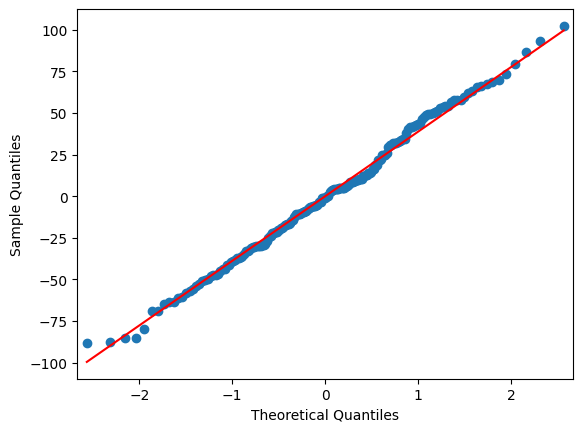

In [45]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson
fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

In [106]:
import pickle

with open('/home/mplitt/shuffle_pkls/licks_sum_mixedlm_shuffle.pkl', 'rb') as file:
    res_dict = pickle.load(file)

In [107]:
res_dict.keys()

dict_keys(['rzone_licks', 'rzone_licks_rank'])

In [114]:
for stat in res_dict.keys():
    coef = res_dict[stat]['genotype coef.']
    shuff_coef = res_dict[stat]['shuffle genotype coef.']

    p = (1.*(coef<shuff_coef)).sum()/shuff_coef.shape[0]
    p = np.minimum(p, 1-p)
    print(f"{stat} : p={p}")

rzone_licks : p=0.018881118881118875
rzone_licks_rank : p=0.019842657342657333
